# Payment Analysis

This notebook analyzes payment methods and payment behavior across orders.

## Payment Methods

This section examines the distribution of payment methods and their contribution to order value.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

payments = pd.read_csv(
    DATA_DIR / "olist_order_payments_dataset.csv"
)

In [2]:
payments.shape

(103886, 5)

In [3]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [4]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [5]:
payments["order_id"].nunique()

99440

In [6]:
payments["order_id"].duplicated().sum()

np.int64(4446)

In [7]:
payments["order_id"].value_counts().head(10)

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
fedcd9f7ccdc8cba3a18defedd1a5547    19
21577126c19bf11a0b91592e5844ba78    15
4bfcba9e084f46c8e3cb49b0fa6e6159    15
3c58bffb70dcf45f12bdf66a3c215905    14
4689b1816de42507a7d63a4617383c59    14
Name: count, dtype: int64

In [8]:
payments.groupby("order_id").size().value_counts().sort_index()

1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64

In [9]:
order_payments = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_count=("payment_sequential", "count")
    )
)

In [10]:
order_payments["payment_count"].value_counts().sort_index()

payment_count
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64

In [11]:
order_payments["payment_value"].describe()

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: payment_value, dtype: float64

In [12]:
payment_type_per_order = (
    payments
    .groupby("order_id")["payment_type"]
    .nunique()
)

payment_type_per_order.value_counts().sort_index()

payment_type
1    97194
2     2246
Name: count, dtype: int64

In [13]:
(payment_type_per_order > 1).sum()

np.int64(2246)

In [14]:
payment_method_summary = (
    payments
    .groupby("payment_type")
    .agg(
        payment_records=("order_id", "count"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean")
    )
    .sort_values("total_payment_value", ascending=False)
)

payment_method_summary

,payment_records,total_payment_value,avg_payment_value
payment_type,,,
credit_card,76795,12542084.19,163.319021
boleto,19784,2869361.27,145.034435
voucher,5775,379436.87,65.703354
debit_card,1529,217989.79,142.570170
not_defined,3,0.00,0.000000


In [15]:
payment_method_summary["payment_value_share"] = (
    payment_method_summary["total_payment_value"]
    / payment_method_summary["total_payment_value"].sum()
)

In [16]:
payment_method_summary

,payment_records,total_payment_value,avg_payment_value,payment_value_share
payment_type,,,,
credit_card,76795,12542084.19,163.319021,0.783446
boleto,19784,2869361.27,145.034435,0.179236
voucher,5775,379436.87,65.703354,0.023702
debit_card,1529,217989.79,142.570170,0.013617
not_defined,3,0.00,0.000000,0.000000


In [17]:
installment_summary = (
    payments
    .groupby("payment_installments")
    .agg(
        payment_records=("order_id", "count"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean")
    )
    .sort_index()
)

installment_summary

,payment_records,total_payment_value,avg_payment_value
payment_installments,,,
0,2,188.63,94.315000
1,52546,5907233.36,112.420229
2,12413,1579283.03,127.228150
3,10461,1491103.80,142.539317
4,7098,1163907.61,163.976840
5,5239,961174.30,183.465222
6,3920,822611.81,209.849952
7,1626,305157.39,187.673672
8,4268,1313423.34,307.737427


In [18]:
installment_orders = (
    payments
    .groupby("payment_installments")["order_id"]
    .nunique()
    .sort_index()
)

installment_orders

payment_installments
0         2
1     49060
2     12389
3     10443
4      7088
5      5234
6      3916
7      1623
8      4253
9       644
10     5315
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: order_id, dtype: int64

In [19]:
installment_main = (
    installment_summary
    .loc[1:10]
    .copy()
)

installment_main

,payment_records,total_payment_value,avg_payment_value
payment_installments,,,
1,52546,5907233.36,112.420229
2,12413,1579283.03,127.228150
3,10461,1491103.80,142.539317
4,7098,1163907.61,163.976840
5,5239,961174.30,183.465222
6,3920,822611.81,209.849952
7,1626,305157.39,187.673672
8,4268,1313423.34,307.737427
9,644,131015.92,203.440870


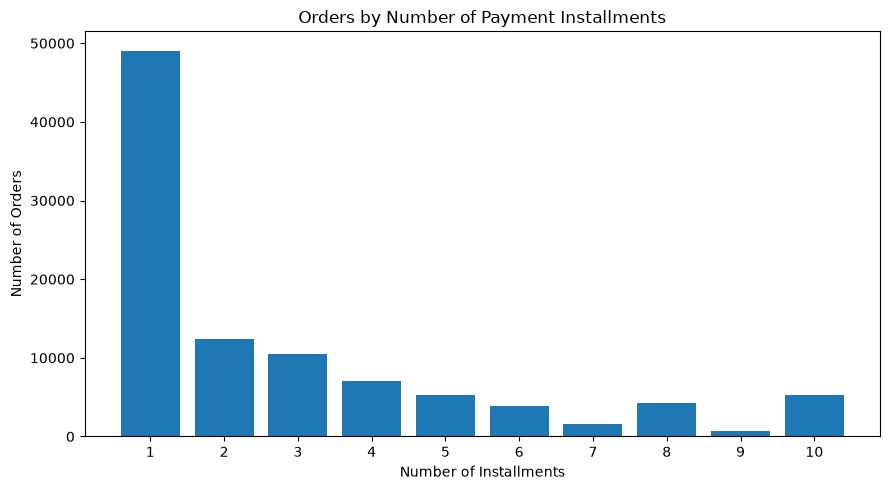

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    installment_main.index,
    installment_orders.loc[1:10]
)

plt.title("Orders by Number of Payment Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Orders")
plt.xticks(range(1, 11))

plt.tight_layout()
plt.show()

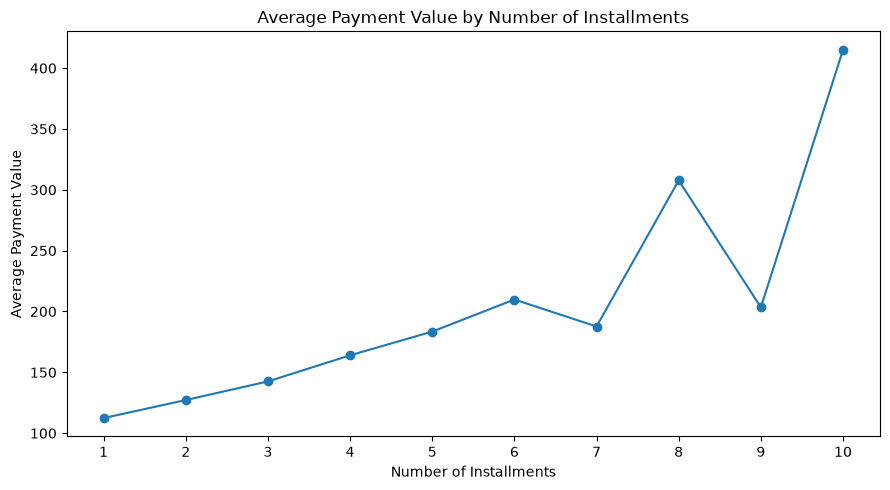

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    installment_main.index,
    installment_main["avg_payment_value"],
    marker="o"
)

plt.title("Average Payment Value by Number of Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Average Payment Value")
plt.xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [22]:
main_installment_share = (
    installment_orders.loc[1:6].sum()
    / installment_orders.sum()
)

main_installment_share

np.float64(0.8785939306934641)

In [23]:
installment_orders.loc[1:10].sum() / installment_orders.sum()

np.float64(0.9965805319615584)

## Key Finding

Most orders are paid in a relatively small number of installments. About 87.9% of orders use between 1 and 6 installments, while 99.7% use between 1 and 10 installments.

Higher installment counts are generally associated with higher average payment values, although the relationship is not strictly monotonic.

## Payment Method and Order Value

This section compares order value across different payment methods.
Only orders with a single payment method are included to avoid ambiguity in assigning a payment method to an order.

In [24]:
single_method_orders = (
    payments
    .groupby("order_id")
    .agg(
        payment_method_count=("payment_type", "nunique"),
        payment_value=("payment_value", "sum"),
        payment_type=("payment_type", "first")
    )
    .query("payment_method_count == 1")
    .drop(columns="payment_method_count")
)

single_method_orders.head()

,payment_value,payment_type
order_id,,
00010242fe8c5a6d1ba2dd792cb16214,72.19,credit_card
00018f77f2f0320c557190d7a144bdd3,259.83,credit_card
000229ec398224ef6ca0657da4fc703e,216.87,credit_card
00024acbcdf0a6daa1e931b038114c75,25.78,credit_card
00042b26cf59d7ce69dfabb4e55b4fd9,218.04,credit_card


In [25]:
single_method_orders.shape

(97194, 2)

In [26]:
single_method_orders["payment_type"].value_counts()

payment_type
credit_card    74259
boleto         19784
voucher         1621
debit_card      1527
not_defined        3
Name: count, dtype: int64

In [27]:
payment_method_value = (
    single_method_orders
    .groupby("payment_type")
    .agg(
        orders=("payment_value", "count"),
        avg_order_value=("payment_value", "mean"),
        median_order_value=("payment_value", "median"),
        total_order_value=("payment_value", "sum")
    )
    .sort_values("avg_order_value", ascending=False)
)

payment_method_value

,orders,avg_order_value,median_order_value,total_order_value
payment_type,,,,
credit_card,74259,166.946479,109.35,12397278.59
boleto,19784,145.034435,93.89,2869361.27
debit_card,1527,142.724158,89.30,217939.79
voucher,1621,114.387588,71.63,185422.28
not_defined,3,0.000000,0.00,0.00


In [28]:
payment_method_value["order_value_share"] = (
    payment_method_value["total_order_value"]
    / payment_method_value["total_order_value"].sum()
)

payment_method_value

,orders,avg_order_value,median_order_value,total_order_value,order_value_share
payment_type,,,,,
credit_card,74259,166.946479,109.35,12397278.59,0.791147
boleto,19784,145.034435,93.89,2869361.27,0.183112
debit_card,1527,142.724158,89.30,217939.79,0.013908
voucher,1621,114.387588,71.63,185422.28,0.011833
not_defined,3,0.000000,0.00,0.00,0.000000


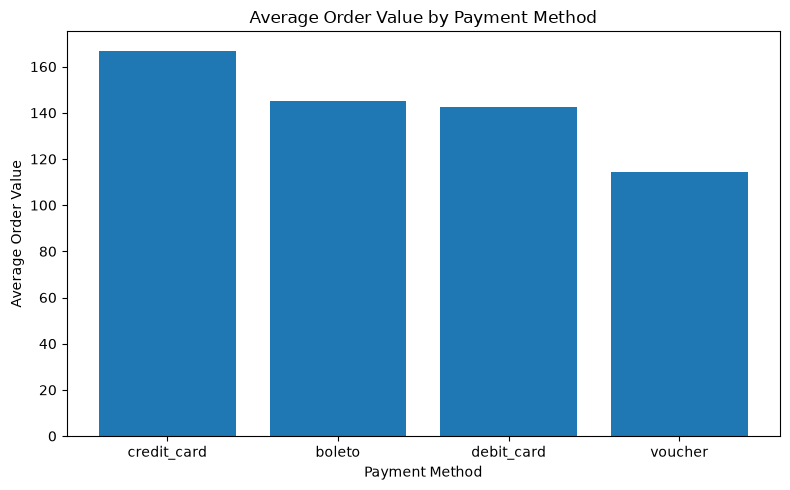

In [29]:
import matplotlib.pyplot as plt

plot_data = payment_method_value.drop(
    index="not_defined"
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data.index,
    plot_data["avg_order_value"]
)

plt.title("Average Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

## Key Finding

Orders paid by credit card had the highest average order value at 166.95, while voucher payments had the lowest at 114.39. Credit card payments also accounted for about 79.1% of the total order value among orders with a single payment method.